# Deep EDA — Multi-Person UWB Localization

**Project:** Embedded and Edge AI — Multi-radar multi-person localization on ESP32-S3
**Notebook role:** First exploration of the dataset. Output of this notebook feeds Section 4 (*Dataset and Problem Analysis*) of the report.

**What this notebook covers**
1. Sensor setup and metadata
2. Window inventory and shape verification
3. Per-window deep dive on one example
4. Occupancy histograms across all 24 windows
5. Ground-truth trajectories per window
6. Raw CIR examples (I/Q, magnitude, range-time maps)
7. Clutter removal preview
8. Per-radar SNR analysis
9. Motion histograms (velocity distributions)
10. Summary table and key findings


## 0. Setup


In [1]:
# Standard libs
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=3, suppress=True)


In [2]:
# Paths (notebook lives in other_files/, dataset in data/)
ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data" / "multi-person-localization"
WINDOWS_DIR = DATA_DIR / "data"
METADATA_PATH = DATA_DIR / "metadata.jsonl"
SENSOR_SETUP_PATH = DATA_DIR / "sensor_setup.json"
LAYOUT_PNG = DATA_DIR / "layout_radar_positions.png"

# Sanity check
assert DATA_DIR.exists(), f"Dataset folder not found: {DATA_DIR}"
window_files = sorted(WINDOWS_DIR.glob("window_*.npz"))
print(f"Found {len(window_files)} window files")
print(f"First: {window_files[0].name}")
print(f"Last:  {window_files[-1].name}")

# Output dir for figures we'll later drop into the report
FIG_DIR = ROOT / "other_files" / "figs_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}")


Found 24 window files
First: window_000000.npz
Last:  window_000023.npz
Figures will be saved to: /home/aman/Projects/TinyML-UWB-MultiPerson-Localization/other_files/figs_eda


## 1. Sensor Setup and Metadata

The two non-`.npz` files describe the experimental setup. Read them once and refer back.


In [ ]:
with open(SENSOR_SETUP_PATH) as f:
    sensor_setup = json.load(f)

print(json.dumps(sensor_setup, indent=2))


{
  "dataset_name": "Multi-Radar Multi-Antenna CIR People Tracking",
  "fps": 25,
  "num_radars": 6,
  "num_antennas_per_radar": 3,
  "cir_bins": 120,
  "iq_representation": "last dimension = [I, Q]",
  "radar_order": [
    "SR250_1",
    "SR250_2",
    "SR250_3",
    "SR250_4",
    "SR250_5",
    "SR250_6"
  ],
  "antenna_order": [
    "rx0",
    "rx1",
    "rx2"
  ],
  "radar_positions_xyz_m": {
    "SR250_1": [
      2.4,
      0.0,
      1.2
    ],
    "SR250_2": [
      4.8,
      1.8,
      1.2
    ],
    "SR250_3": [
      4.8,
      5.4,
      1.2
    ],
    "SR250_4": [
      2.4,
      7.2,
      1.2
    ],
    "SR250_5": [
      0.0,
      5.4,
      1.2
    ],
    "SR250_6": [
      0.0,
      1.8,
      1.2
    ]
  },
  "coordinate_system": {
    "origin": "bottom_left_corner_room",
    "x_axis": "horizontal_positive_right",
    "y_axis": "vertical_positive_up"
  },
  "max_people": 4,
  "people_representation": "zero padded with mask",
  "position_units": "meters"
}


In [17]:
ROOM_W = 4.8
ROOM_H = 7.2

print(f"Room dimensions: {ROOM_W}m x {ROOM_H}m")

Room dimensions: 4.8m x 7.2m


In [13]:
# Radar positions, in the same order as axis 1 of radar_cir_iq
radar_order = sensor_setup["radar_order"]
radar_positions = np.array([sensor_setup["radar_positions_xyz_m"][n] for n in radar_order])  # (6, 3): x, y, z

print("Radar positions (axis-1 order of radar_cir_iq):")
for i, (name, pos) in enumerate(zip(radar_order, radar_positions)):
    print(f"  idx {i}  {name}: x={pos[0]:.2f}m  y={pos[1]:.2f}m  z={pos[2]:.2f}m")

print(f"\nAll mounted at z = {radar_positions[:,2].mean():.2f} m on the room perimeter.")

Radar positions (axis-1 order of radar_cir_iq):
  idx 0  SR250_1: x=2.40m  y=0.00m  z=1.20m
  idx 1  SR250_2: x=4.80m  y=1.80m  z=1.20m
  idx 2  SR250_3: x=4.80m  y=5.40m  z=1.20m
  idx 3  SR250_4: x=2.40m  y=7.20m  z=1.20m
  idx 4  SR250_5: x=0.00m  y=5.40m  z=1.20m
  idx 5  SR250_6: x=0.00m  y=1.80m  z=1.20m

All mounted at z = 1.20 m on the room perimeter.


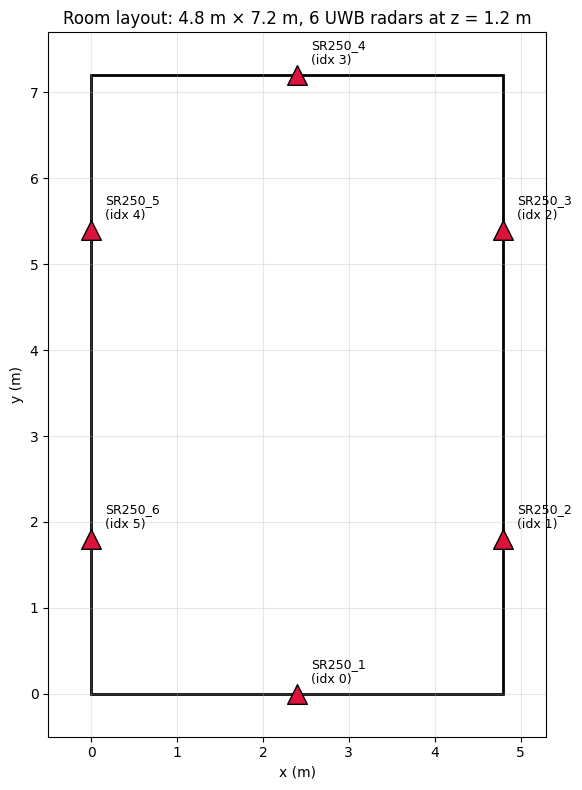

In [18]:
# Room layout figure - useful as Figure 1 in the report
fig, ax = plt.subplots(figsize=(6, 8))
ax.add_patch(patches.Rectangle((0, 0), ROOM_W, ROOM_H, fill=False, edgecolor="black", linewidth=2))
for i, (name, pos) in enumerate(zip(radar_order, radar_positions)):
    ax.scatter(pos[0], pos[1], s=200, marker="^", color="crimson", edgecolor="black", zorder=3)
    ax.annotate(f"{name}\n(idx {i})", (pos[0], pos[1]),
                textcoords="offset points", xytext=(10, 8), fontsize=9)
ax.set_xlim(-0.5, ROOM_W + 0.5)
ax.set_ylim(-0.5, ROOM_H + 0.5)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Room layout: {ROOM_W} m × {ROOM_H} m, 6 UWB radars at z = 1.2 m")
plt.tight_layout()
plt.savefig(FIG_DIR / "room_layout.png", bbox_inches="tight")
plt.show()

In [5]:
# Metadata is JSONL: one record per acquisition window
metadata_records = []
with open(METADATA_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            metadata_records.append(json.loads(line))

metadata_df = pd.DataFrame(metadata_records)
print(f"Metadata records: {len(metadata_df)}")
print("Columns:", list(metadata_df.columns))
metadata_df.head(10)


Metadata records: 24
Columns: ['window_id', 'path', 'num_frames', 'duration_sec', 'description', 'acquisition_timestamp']


,window_id,path,num_frames,duration_sec,description,acquisition_timestamp
0,window_000000,data/window_000000.npz,7500,300.0,random walk of 2 subjects,20260220-112438
1,window_000001,data/window_000001.npz,7500,300.0,"random walk of 2 subjects, one to the left of ...",20260220-113155
2,window_000002,data/window_000002.npz,7500,300.0,"random walk of 2 subjects, one above the line ...",20260220-113848
3,window_000003,data/window_000003.npz,7500,300.0,random walk of 2 subjects,20260220-114524
4,window_000004,data/window_000004.npz,7500,300.0,random walk of 1 subject while the other is se...,20260220-115314
5,window_000005,data/window_000005.npz,7500,300.0,random walk of 4 subjects,20260306-103626
6,window_000006,data/window_000006.npz,7500,300.0,random walk of 4 subjects,20260306-104232
7,window_000007,data/window_000007.npz,7500,300.0,random walk of 4 subjects,20260306-104815
8,window_000008,data/window_000008.npz,7500,300.0,random walk of 3 subjects and 1 seated subject,20260306-105449
9,window_000009,data/window_000009.npz,7500,300.0,random walk of 3 subjects and 1 seated subject,20260306-110056


## 2. Window Inventory and Shape Verification

Loop over all 24 windows and verify the shapes match the spec:

| Array         | Spec shape         |
|---------------|--------------------|
| `radar_cir_iq` | `(T, 6, 3, 120, 2)` |
| `people_xy`    | `(T, 4, 2)`         |
| `people_mask`  | `(T, 4)`            |
| `timestamps`   | `(T,)`              |


In [7]:
def load_window(path):
    """Load a window .npz file as a dict of numpy arrays."""
    with np.load(path) as f:
        return {k: f[k] for k in f.files}

inventory = []
for path in window_files:
    w = load_window(path)
    rec = {
        "window": path.stem,
        "T": w["radar_cir_iq"].shape[0],
        "cir_shape": tuple(w["radar_cir_iq"].shape),
        "cir_dtype": str(w["radar_cir_iq"].dtype),
        "xy_shape": tuple(w["people_xy"].shape),
        "mask_shape": tuple(w["people_mask"].shape),
        "ts_shape": tuple(w["timestamps"].shape),
        "duration_s": float(w["timestamps"][-1] - w["timestamps"][0]) if w["timestamps"].size > 1 else 0.0,
        "max_people": int(w["people_mask"].sum(axis=1).max()),
        "mean_people": float(w["people_mask"].sum(axis=1).mean()),
    }
    inventory.append(rec)

inventory_df = pd.DataFrame(inventory)
inventory_df


,window,T,cir_shape,cir_dtype,xy_shape,mask_shape,ts_shape,duration_s,max_people,mean_people
0,window_000000,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,2,2.0
1,window_000001,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,2,2.0
2,window_000002,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,2,2.0
3,window_000003,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,2,2.0
4,window_000004,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,2,2.0
5,window_000005,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,4,4.0
6,window_000006,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,4,4.0
7,window_000007,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,4,4.0
8,window_000008,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,4,4.0
9,window_000009,7500,"(7500, 6, 3, 120, 2)",float32,"(7500, 4, 2)","(7500, 4)","(7500,)",299.959991,4,4.0


In [8]:
# Spec compliance check
spec_cir = (None, 6, 3, 120, 2)  # T is variable
spec_xy = (None, 4, 2)
spec_mask = (None, 4)

bad = []
for rec in inventory:
    if rec["cir_shape"][1:] != spec_cir[1:]:
        bad.append((rec["window"], "cir", rec["cir_shape"]))
    if rec["xy_shape"][1:] != spec_xy[1:]:
        bad.append((rec["window"], "xy", rec["xy_shape"]))
    if rec["mask_shape"][1:] != spec_mask[1:]:
        bad.append((rec["window"], "mask", rec["mask_shape"]))

if bad:
    print("Windows that DO NOT match spec:")
    for b in bad:
        print(" ", b)
else:
    print("All 24 windows match the spec shapes.")

print(f"\nTotal frames: {inventory_df['T'].sum():,}")
print(f"Total duration: {inventory_df['duration_s'].sum():.1f} s "
      f"({inventory_df['duration_s'].sum()/60:.1f} min)")
print(f"Mean sample rate: {inventory_df['T'].sum()/inventory_df['duration_s'].sum():.2f} Hz "
      f"(spec: 25 Hz)")


All 24 windows match the spec shapes.

Total frames: 180,000
Total duration: 7199.0 s (120.0 min)
Mean sample rate: 25.00 Hz (spec: 25 Hz)


## 3. Per-Window Deep Dive

Pick one representative window and fully unpack it. This tells us exactly what the model will consume.


In [9]:
# Choose a window with multiple people
example_idx = int(inventory_df["max_people"].idxmax())
example_path = window_files[example_idx]
print(f"Example window: {example_path.name} (max {inventory_df.loc[example_idx, 'max_people']} people)")

W = load_window(example_path)
for k, v in W.items():
    print(f"  {k:15s} shape={v.shape}  dtype={v.dtype}")


Example window: window_000005.npz (max 4 people)
  radar_cir_iq    shape=(7500, 6, 3, 120, 2)  dtype=float32
  people_xy       shape=(7500, 4, 2)  dtype=float32
  people_mask     shape=(7500, 4)  dtype=uint8
  timestamps      shape=(7500,)  dtype=float32


In [10]:
# Unpack into named variables for clarity in later cells
cir_iq      = W["radar_cir_iq"]    # (T, 6, 3, 120, 2)  -- I/Q
people_xy   = W["people_xy"]       # (T, 4, 2)
people_mask = W["people_mask"]     # (T, 4)  bool
timestamps  = W["timestamps"]      # (T,)

T, N_RADARS, N_ANT, N_BINS, _ = cir_iq.shape
print(f"T={T}, radars={N_RADARS}, antennas={N_ANT}, range bins={N_BINS}")
print(f"Time span: {timestamps[0]:.2f}s to {timestamps[-1]:.2f}s "
      f"({timestamps[-1]-timestamps[0]:.1f}s)")

dt = np.diff(timestamps)
print(f"Frame interval: mean={dt.mean()*1000:.1f} ms  std={dt.std()*1000:.2f} ms  "
      f"(=> {1/dt.mean():.2f} Hz)")

# Convert I/Q to complex once for later use
cir_complex = cir_iq[..., 0] + 1j * cir_iq[..., 1]   # (T, 6, 3, 120)
cir_mag = np.abs(cir_complex)                          # (T, 6, 3, 120)
print(f"cir_complex: {cir_complex.shape}, {cir_complex.dtype}")
print(f"cir_mag stats: min={cir_mag.min():.3g}, max={cir_mag.max():.3g}, mean={cir_mag.mean():.3g}")


T=7500, radars=6, antennas=3, range bins=120
Time span: 0.00s to 299.96s (300.0s)
Frame interval: mean=40.0 ms  std=0.01 ms  (=> 25.00 Hz)
cir_complex: (7500, 6, 3, 120), complex64
cir_mag stats: min=0, max=3.56e+04, mean=1.34e+03


## 4. Occupancy Histogram (across all 24 windows)

For each frame, count how many of the 4 slots are valid. This shows class imbalance — empty room vs. 1/2/3/4 people.


In [11]:
occupancy_counts = Counter()  # frames-per-occupancy across the whole dataset
per_window_occupancy = []     # one Counter per window, for stratification

for path in window_files:
    with np.load(path) as f:
        mask = f["people_mask"]              # (T, 4)
    n_people = mask.sum(axis=1).astype(int)  # (T,)
    c = Counter(n_people.tolist())
    per_window_occupancy.append(c)
    occupancy_counts.update(c)

total = sum(occupancy_counts.values())
print(f"Total frames: {total:,}\n")
for k in sorted(occupancy_counts):
    n = occupancy_counts[k]
    print(f"  {k} people: {n:>7,} frames  ({100*n/total:5.2f} %)")


Total frames: 180,000

  0 people:  15,000 frames  ( 8.33 %)
  1 people:  45,000 frames  (25.00 %)
  2 people:  37,500 frames  (20.83 %)
  3 people:  30,000 frames  (16.67 %)
  4 people:  52,500 frames  (29.17 %)


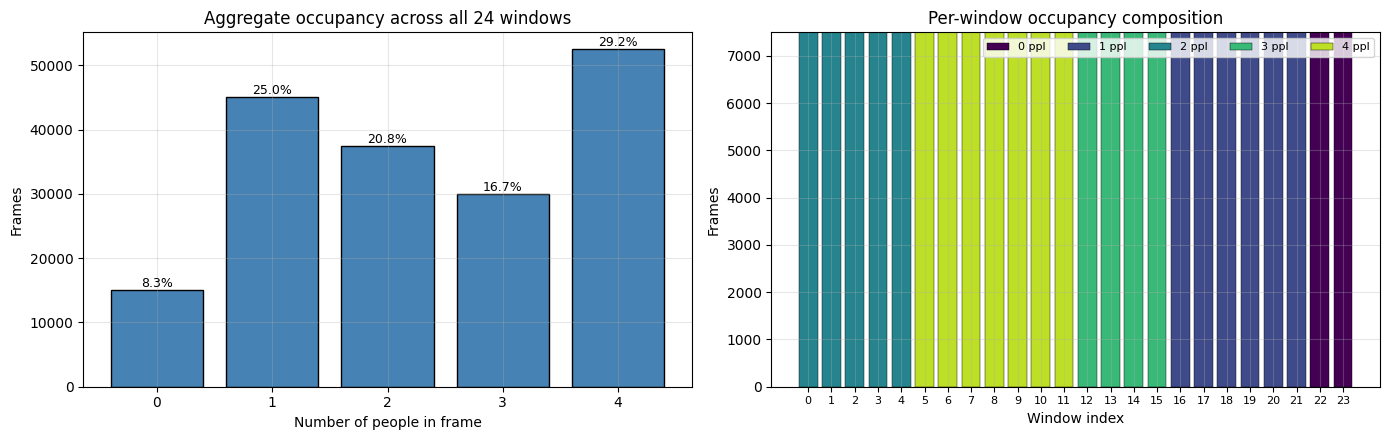

In [ ]:
# Aggregate plot + per-window stacked bar
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# --- Aggregate
ks = sorted(occupancy_counts)
vals = [occupancy_counts[k] for k in ks]
axes[0].bar(ks, vals, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Number of people in frame")
axes[0].set_ylabel("Frames")
axes[0].set_title("Aggregate occupancy across all 24 windows")
axes[0].set_xticks(ks)
for k, v in zip(ks, vals):
    axes[0].text(k, v, f"{100*v/total:.1f}%", ha="center", va="bottom", fontsize=9)

# --- Per-window stacked bar
window_names = [p.stem.replace("window_", "w") for p in window_files]
n_windows = len(window_files)
all_levels = sorted({lvl for c in per_window_occupancy for lvl in c})
matrix = np.zeros((len(all_levels), n_windows), dtype=int)
for j, c in enumerate(per_window_occupancy):
    for i, lvl in enumerate(all_levels):
        matrix[i, j] = c.get(lvl, 0)

bottom = np.zeros(n_windows)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(all_levels)))# Radar positions, in the same order as axis 1 of radar_cir_iq
radar_order = sensor_setup["radar_order"]
radar_positions = np.array([sensor_setup["radar_positions_xyz_m"][n] for n in radar_order])  # (6, 3): x, y, z

print("Radar positions (axis-1 order of radar_cir_iq):")
for i, (name, pos) in enumerate(zip(radar_order, radar_positions)):
    print(f"  idx {i}  {name}: x={pos[0]:.2f}m  y={pos[1]:.2f}m  z={pos[2]:.2f}m")

print(f"\nAll mounted at z = {radar_positions[:,2].mean():.2f} m on the room perimeter.")
for i, lvl in enumerate(all_levels):
    axes[1].bar(range(n_windows), matrix[i], bottom=bottom, label=f"{lvl} ppl",
                color=colors[i], edgecolor="black", linewidth=0.3)
    bottom += matrix[i]
axes[1].set_xlabel("Window index")
axes[1].set_ylabel("Frames")
axes[1].set_title("Per-window occupancy composition")
axes[1].set_xticks(range(n_windows))
axes[1].set_xticklabels([str(i) for i in range(n_windows)], fontsize=8)
axes[1].legend(loc="upper right", ncol=len(all_levels), fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "occupancy_histogram.png", bbox_inches="tight")
plt.show()


## 5. Ground-Truth Trajectories per Window

Plot each window's (x, y) tracks on the room floorplan. This reveals walking vs. seated vs. serpentine patterns and confirms the room dimensions.


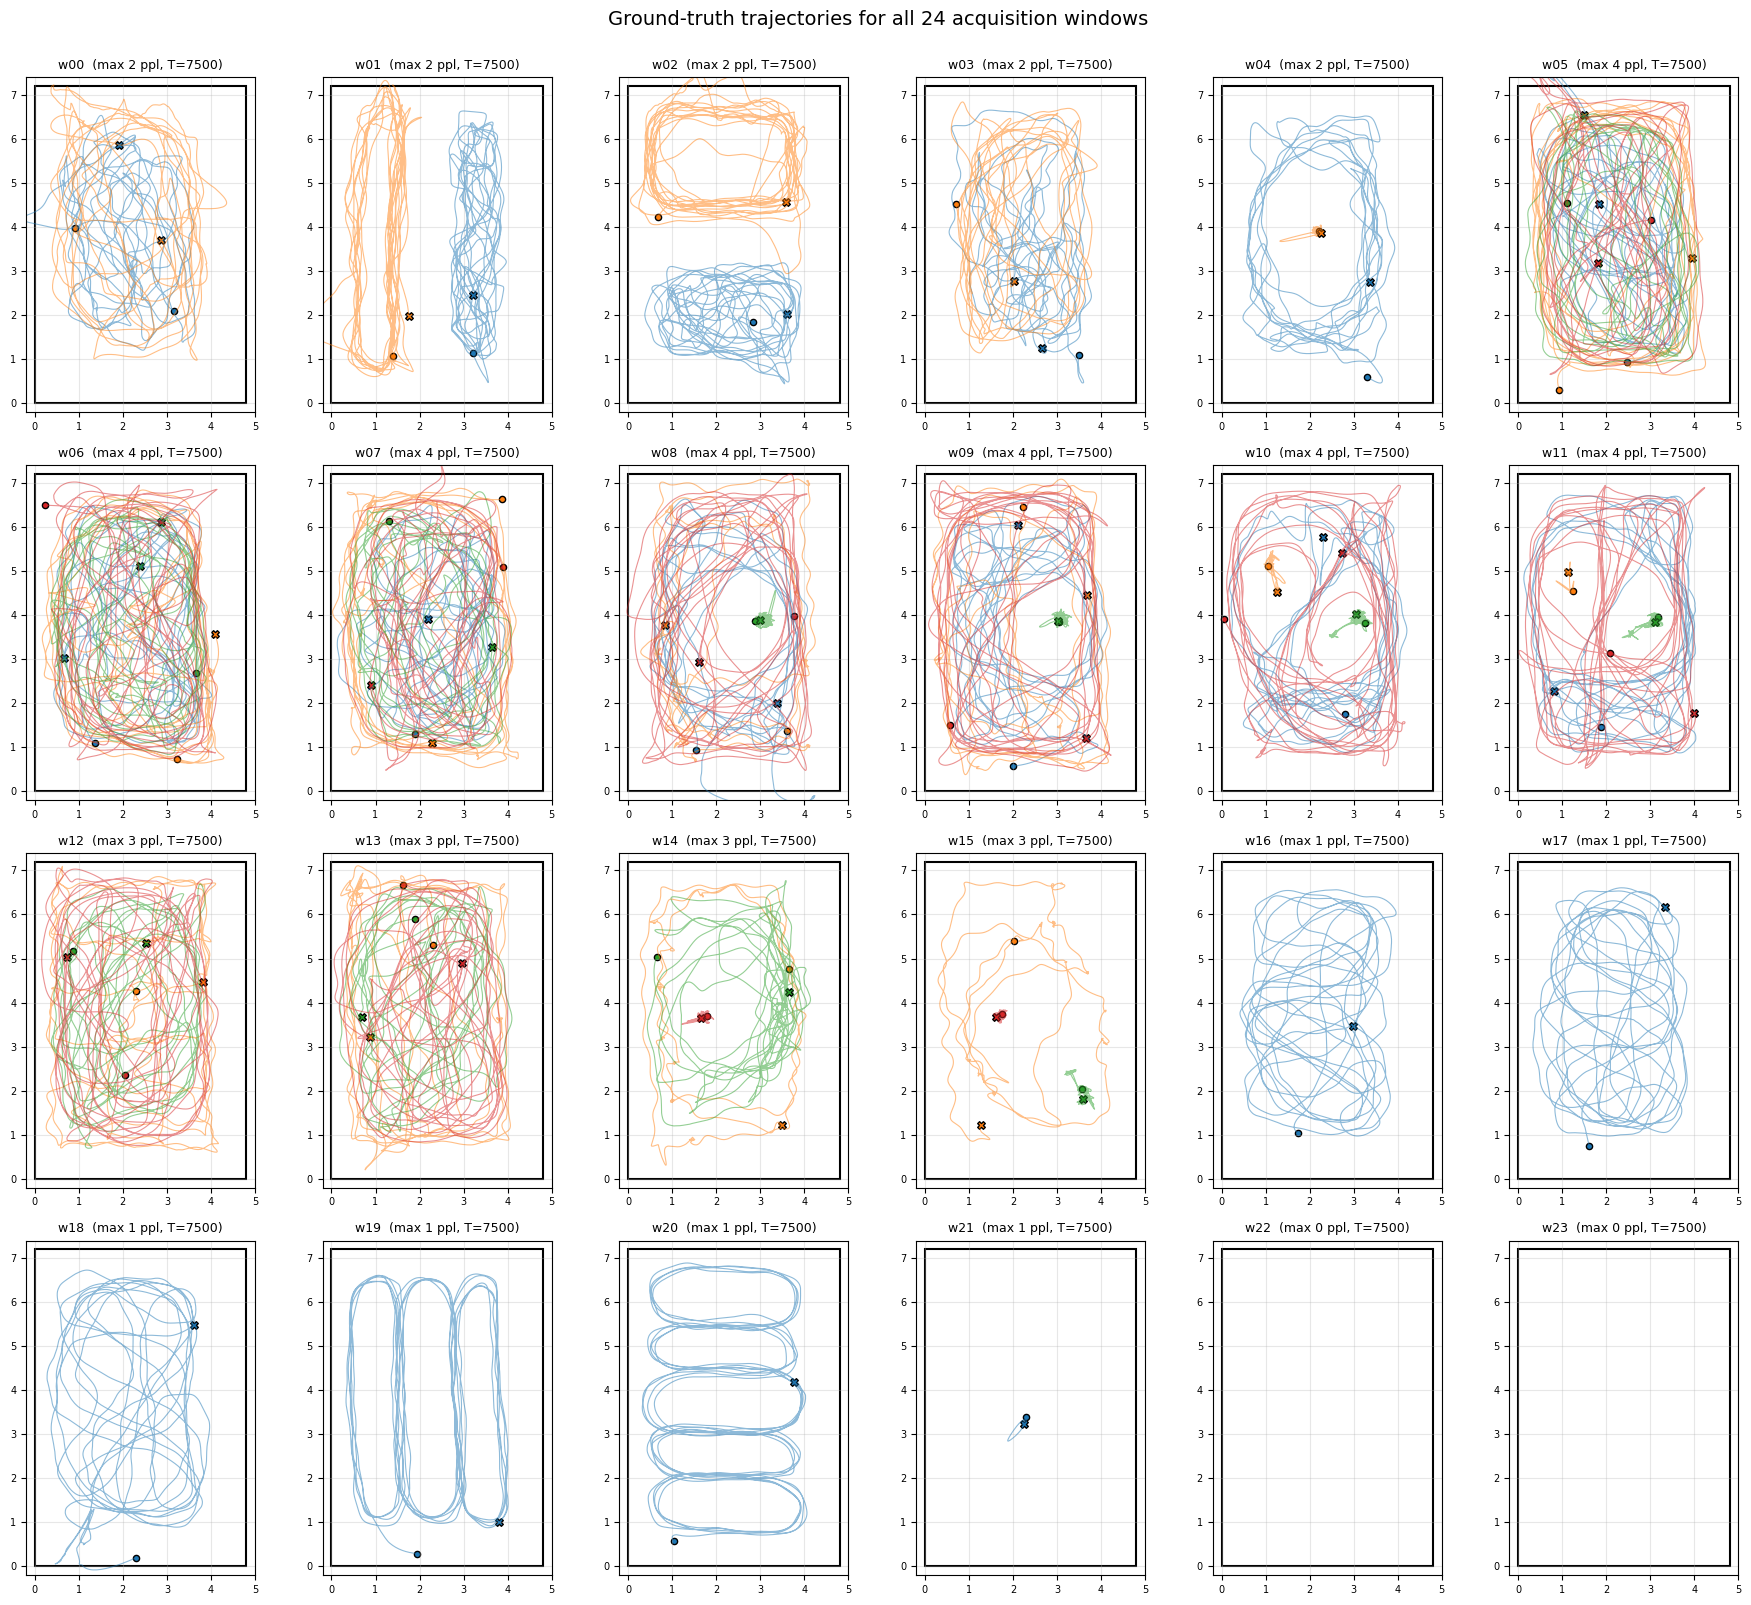

In [20]:
ROOM_W, ROOM_H = 4.8, 7.2   # metres, from the assignment

def plot_trajectories(ax, people_xy, people_mask, radar_positions=None, title=""):
    ax.add_patch(patches.Rectangle((0, 0), ROOM_W, ROOM_H,
                                   fill=False, edgecolor="black", linewidth=1.5))
    palette = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    for slot in range(people_xy.shape[1]):
        valid = people_mask[:, slot].astype(bool)
        if valid.sum() < 2:
            continue
        xs = people_xy[valid, slot, 0]
        ys = people_xy[valid, slot, 1]
        ax.plot(xs, ys, "-", color=palette[slot], alpha=0.5, linewidth=0.8)
        ax.scatter(xs[0],  ys[0],  marker="o", s=20, color=palette[slot], edgecolor="black")
        ax.scatter(xs[-1], ys[-1], marker="X", s=30, color=palette[slot], edgecolor="black")
    if radar_positions is not None:
        ax.scatter(radar_positions[:, 0], radar_positions[:, 1],
                   marker="^", s=40, color="crimson", edgecolor="black", zorder=3)
    ax.set_xlim(-0.2, ROOM_W + 0.2)
    ax.set_ylim(-0.2, ROOM_H + 0.2)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=7)

# Grid of all 24 windows: 4x6
fig, axes = plt.subplots(4, 6, figsize=(18, 16))
for i, path in enumerate(window_files):
    with np.load(path) as f:
        xy = f["people_xy"]
        mask = f["people_mask"]
    ax = axes.flat[i]
    max_p = int(mask.sum(axis=1).max())
    plot_trajectories(ax, xy, mask, title=f"w{i:02d}  (max {max_p} ppl, T={xy.shape[0]})")

plt.suptitle("Ground-truth trajectories for all 24 acquisition windows", y=1.00, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "trajectories_all_windows.png", bbox_inches="tight")
plt.show()


## 6. Raw CIR Examples

Three views of the same example window:
1. **I and Q over time** at one fixed range bin (sanity check on signal scale and noise floor).
2. **CIR magnitude vs. range bin** for several frames (where in range do reflections live?).
3. **Range–time map** (waterfall) for one antenna of one radar (motion appears as horizontal streaks).


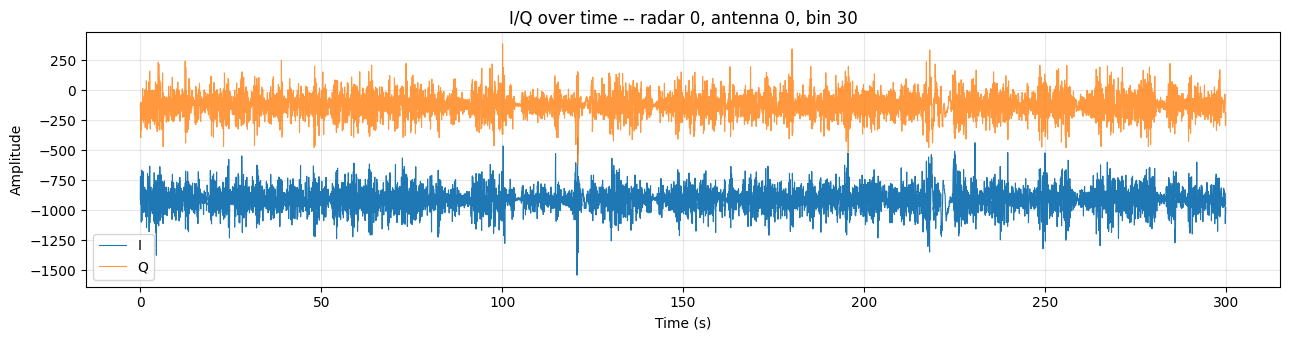

In [21]:
# 6.1 -- I/Q over time at a fixed (radar, antenna, bin)
RADAR_IDX, ANT_IDX, BIN_IDX = 0, 0, 30   # arbitrary; adjust as you explore

I = cir_iq[:, RADAR_IDX, ANT_IDX, BIN_IDX, 0]
Q = cir_iq[:, RADAR_IDX, ANT_IDX, BIN_IDX, 1]

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(timestamps, I, label="I", linewidth=0.8)
ax.plot(timestamps, Q, label="Q", linewidth=0.8, alpha=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"I/Q over time -- radar {RADAR_IDX}, antenna {ANT_IDX}, bin {BIN_IDX}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "cir_iq_over_time.png", bbox_inches="tight")
plt.show()


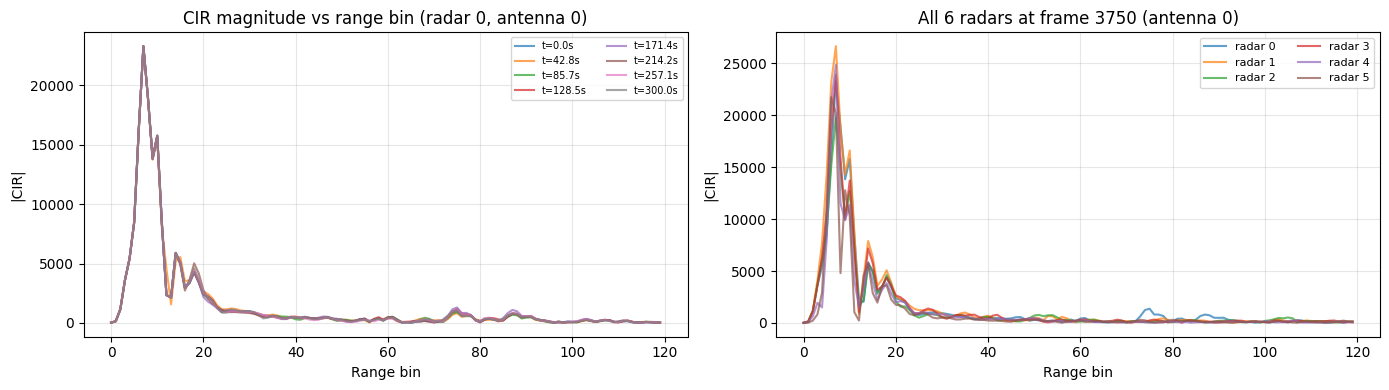

In [22]:
# 6.2 -- CIR magnitude vs range bin, several frames overlaid
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pick a few well-separated frames
sample_frames = np.linspace(0, T-1, 8).astype(int)

ax = axes[0]
for fi in sample_frames:
    ax.plot(cir_mag[fi, RADAR_IDX, ANT_IDX], alpha=0.7, label=f"t={timestamps[fi]:.1f}s")
ax.set_xlabel("Range bin")
ax.set_ylabel("|CIR|")
ax.set_title(f"CIR magnitude vs range bin (radar {RADAR_IDX}, antenna {ANT_IDX})")
ax.legend(fontsize=7, ncol=2)

# Per-radar overlay at a single frame, antenna 0
ax = axes[1]
mid_frame = T // 2
for r in range(N_RADARS):
    ax.plot(cir_mag[mid_frame, r, 0], alpha=0.7, label=f"radar {r}")
ax.set_xlabel("Range bin")
ax.set_ylabel("|CIR|")
ax.set_title(f"All 6 radars at frame {mid_frame} (antenna 0)")
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(FIG_DIR / "cir_magnitude_profiles.png", bbox_inches="tight")
plt.show()


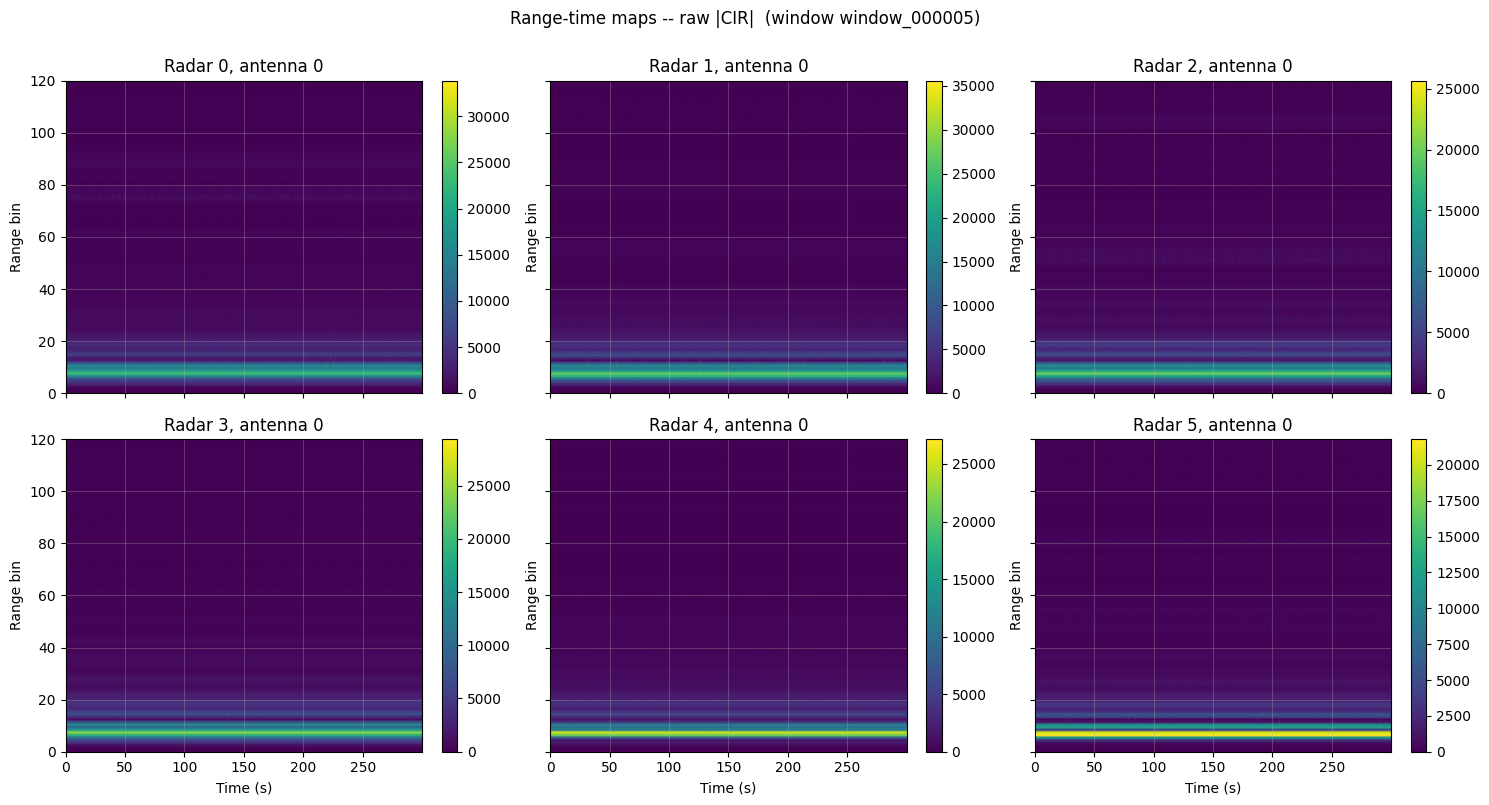

In [23]:
# 6.3 -- Range-time map (waterfall) for one antenna of each radar
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for r in range(N_RADARS):
    ax = axes.flat[r]
    # cir_mag[:, r, 0] is (T, 120) -- transpose so range is on y, time on x
    im = ax.imshow(cir_mag[:, r, 0].T, aspect="auto", origin="lower",
                   extent=[timestamps[0], timestamps[-1], 0, N_BINS],
                   cmap="viridis")
    ax.set_title(f"Radar {r}, antenna 0")
    ax.set_ylabel("Range bin")
    if r >= 3:
        ax.set_xlabel("Time (s)")
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.suptitle(f"Range-time maps -- raw |CIR|  (window {example_path.stem})", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "rangetime_raw.png", bbox_inches="tight")
plt.show()


## 7. Clutter Removal Preview

UWB CIR is dominated by static reflections (walls, furniture). Subtracting a slow-moving mean across time isolates the moving targets — exactly what the localization model needs.

Two simple methods:
- **Running mean subtraction**: `y[t] = x[t] - mean(x[t-W:t])`
- **First-order high-pass**: `y[t] = x[t] - alpha * y[t-1]` with `alpha` close to 1.

We preview the running-mean method here. The change in the range-time map is dramatic.


In [24]:
def remove_clutter_running_mean(cir, window=50, axis=0):
    """Subtract a centered running mean along the time axis."""
    # cumsum trick for fast running mean
    pad = window // 2
    cir_padded = np.concatenate([
        np.repeat(cir[:1], pad, axis=axis),
        cir,
        np.repeat(cir[-1:], pad, axis=axis),
    ], axis=axis)
    # Use np.convolve along axis 0 for each (radar, ant, bin)
    kernel = np.ones(window) / window
    mean = np.apply_along_axis(lambda v: np.convolve(v, kernel, mode="valid"),
                               axis=axis, arr=cir_padded)
    # Trim to original length
    if mean.shape[axis] != cir.shape[axis]:
        mean = mean[:cir.shape[axis]] if axis == 0 else mean
    return cir - mean

cir_mag_clean = remove_clutter_running_mean(cir_mag, window=50, axis=0)
print("After clutter removal:")
print(f"  shape: {cir_mag_clean.shape}")
print(f"  min={cir_mag_clean.min():.3g}, max={cir_mag_clean.max():.3g}, mean={cir_mag_clean.mean():.3g}")


After clutter removal:
  shape: (7500, 6, 3, 120)
  min=-1.24e+04, max=1.47e+04, mean=-0.00169


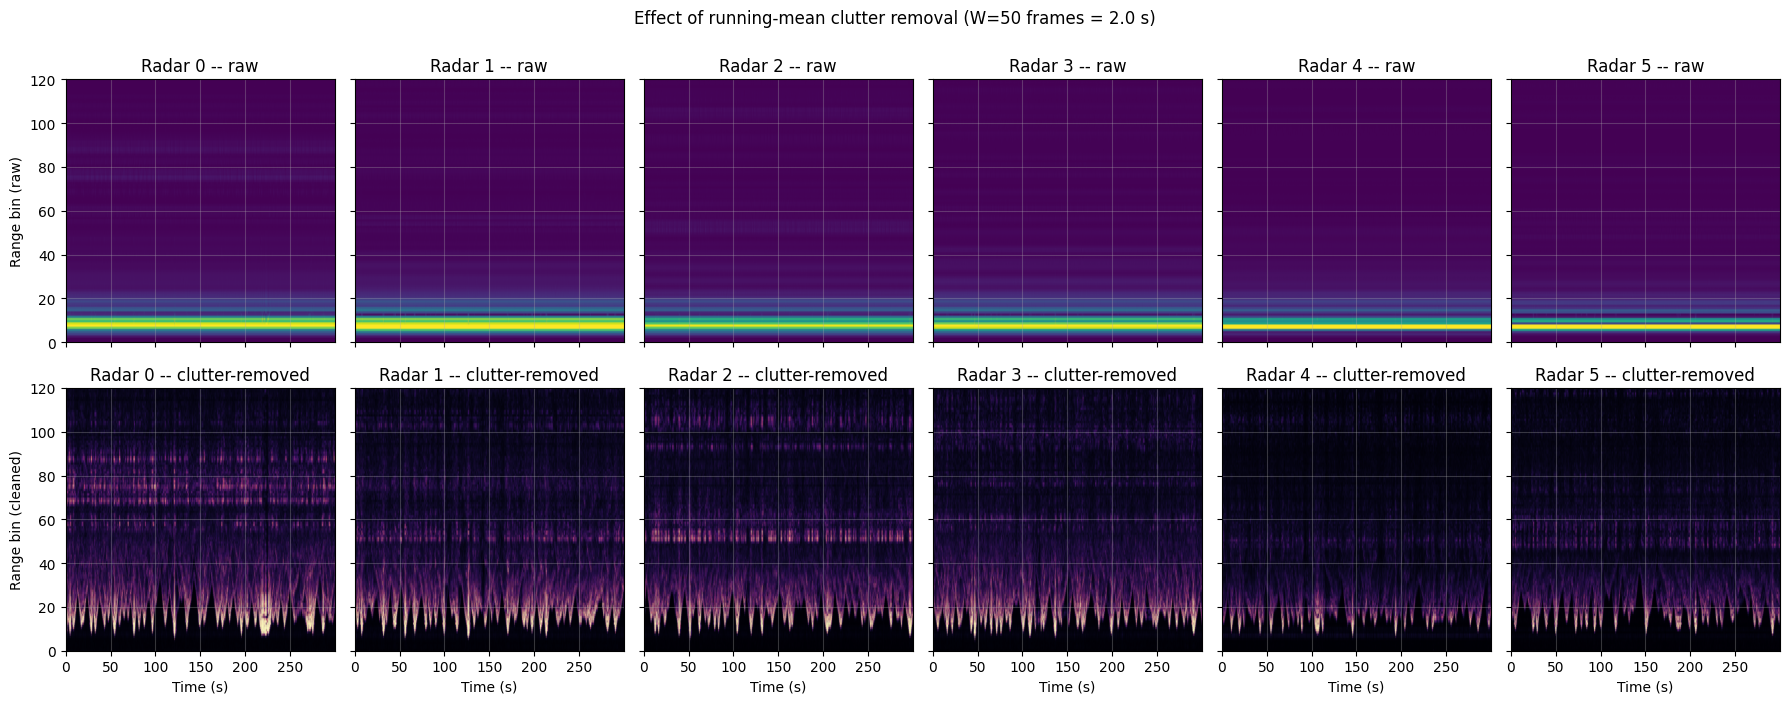

In [25]:
# Side-by-side: raw vs cleaned, one antenna per radar
fig, axes = plt.subplots(2, N_RADARS, figsize=(18, 7), sharex=True, sharey=True)
vmax_raw = np.percentile(cir_mag[:, :, 0], 99)
vmax_clean = np.percentile(np.abs(cir_mag_clean[:, :, 0]), 99)

for r in range(N_RADARS):
    axes[0, r].imshow(cir_mag[:, r, 0].T, aspect="auto", origin="lower",
                      extent=[timestamps[0], timestamps[-1], 0, N_BINS],
                      cmap="viridis", vmin=0, vmax=vmax_raw)
    axes[0, r].set_title(f"Radar {r} -- raw")

    axes[1, r].imshow(np.abs(cir_mag_clean[:, r, 0]).T, aspect="auto", origin="lower",
                      extent=[timestamps[0], timestamps[-1], 0, N_BINS],
                      cmap="magma", vmin=0, vmax=vmax_clean)
    axes[1, r].set_title(f"Radar {r} -- clutter-removed")
    axes[1, r].set_xlabel("Time (s)")

axes[0, 0].set_ylabel("Range bin (raw)")
axes[1, 0].set_ylabel("Range bin (cleaned)")
plt.suptitle("Effect of running-mean clutter removal (W=50 frames = 2.0 s)", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "rangetime_raw_vs_clean.png", bbox_inches="tight")
plt.show()


## 8. Per-Radar SNR Analysis

Crude proxy: after clutter removal, the energy that remains is *mostly* moving targets + noise. We measure each radar's median residual energy across the dataset and compare radars. Radars with consistently lower residual energy may be partially obstructed or further from typical activity.

This informs the **radar subset selection** decision in Section 6.2 of the report.


In [26]:
radar_energies = np.zeros(N_RADARS)
radar_energies_per_window = np.zeros((len(window_files), N_RADARS))

for j, path in enumerate(window_files):
    with np.load(path) as f:
        c = f["radar_cir_iq"][..., 0] + 1j * f["radar_cir_iq"][..., 1]
        m = np.abs(c)  # (T, 6, 3, 120)
    m_clean = remove_clutter_running_mean(m, window=50, axis=0)
    # Energy: mean of squared residual, averaged over antennas, range bins, time
    e = np.mean(m_clean ** 2, axis=(0, 2, 3))  # (6,)
    radar_energies_per_window[j] = e

radar_mean_energy = radar_energies_per_window.mean(axis=0)
radar_med_energy = np.median(radar_energies_per_window, axis=0)

print("Per-radar residual energy (after clutter removal):")
for r in range(N_RADARS):
    print(f"  Radar {r}: mean={radar_mean_energy[r]:.4g}  median={radar_med_energy[r]:.4g}")


Per-radar residual energy (after clutter removal):
  Radar 0: mean=2633  median=1355
  Radar 1: mean=2198  median=1191
  Radar 2: mean=2270  median=1872
  Radar 3: mean=2756  median=2180
  Radar 4: mean=1034  median=839
  Radar 5: mean=1234  median=1218


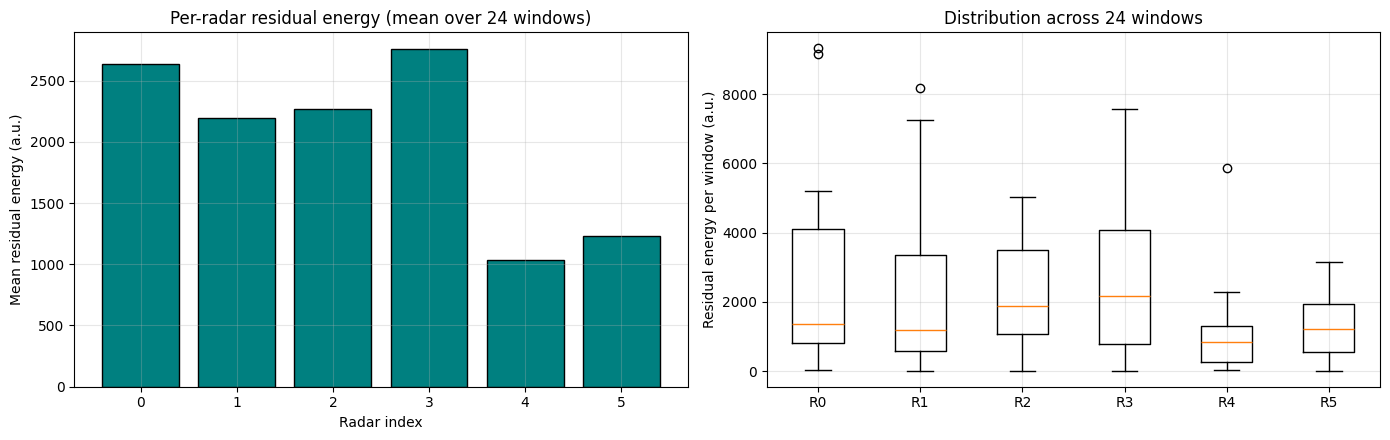

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Bar chart of mean energy
axes[0].bar(range(N_RADARS), radar_mean_energy, color="teal", edgecolor="black")
axes[0].set_xlabel("Radar index")
axes[0].set_ylabel("Mean residual energy (a.u.)")
axes[0].set_title("Per-radar residual energy (mean over 24 windows)")
axes[0].set_xticks(range(N_RADARS))

# Box plot across windows
axes[1].boxplot([radar_energies_per_window[:, r] for r in range(N_RADARS)],
                tick_labels=[f"R{r}" for r in range(N_RADARS)])
axes[1].set_ylabel("Residual energy per window (a.u.)")
axes[1].set_title("Distribution across 24 windows")

plt.tight_layout()
plt.savefig(FIG_DIR / "per_radar_energy.png", bbox_inches="tight")
plt.show()


## 9. Motion Histograms

From `people_xy` and `timestamps` we can derive per-person speed (m/s). The distribution separates static (seated) from walking from fast (serpentine) subjects, and helps decide how much temporal context the model needs.


In [28]:
speeds_all = []
speeds_per_window = []

for path in window_files:
    with np.load(path) as f:
        xy = f["people_xy"]            # (T, 4, 2)
        mask = f["people_mask"]        # (T, 4)
        ts = f["timestamps"]           # (T,)
    dt = np.diff(ts)                   # (T-1,)
    # Per-slot speed: only where mask is True for both consecutive frames
    window_speeds = []
    for slot in range(xy.shape[1]):
        valid = mask[:, slot].astype(bool)
        valid_pair = valid[:-1] & valid[1:]
        if valid_pair.sum() == 0:
            continue
        d = np.linalg.norm(np.diff(xy[:, slot, :], axis=0), axis=1)  # (T-1,)
        s = d / dt
        window_speeds.append(s[valid_pair])
    if window_speeds:
        ws = np.concatenate(window_speeds)
        speeds_per_window.append(ws)
        speeds_all.append(ws)
    else:
        speeds_per_window.append(np.array([]))

speeds_all = np.concatenate(speeds_all) if speeds_all else np.array([])
print(f"Total per-frame per-person speed samples: {len(speeds_all):,}")
print(f"  median: {np.median(speeds_all):.3f} m/s")
print(f"  90th pct: {np.percentile(speeds_all, 90):.3f} m/s")
print(f"  99th pct: {np.percentile(speeds_all, 99):.3f} m/s")
print(f"  max: {speeds_all.max():.3f} m/s")


Total per-frame per-person speed samples: 419,944
  median: 0.438 m/s
  90th pct: 0.683 m/s
  99th pct: 0.858 m/s
  max: 4.005 m/s


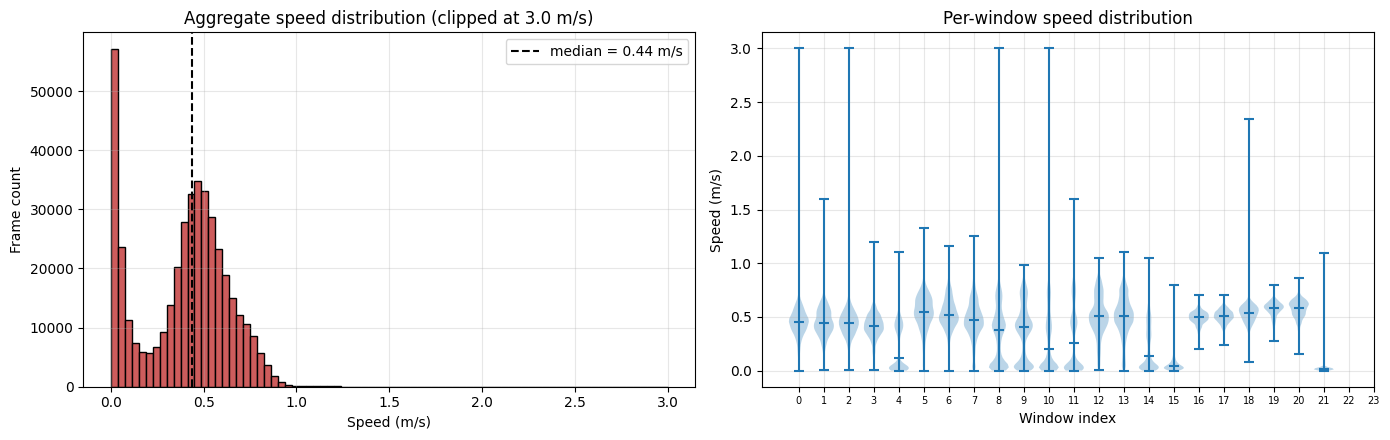

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Aggregate histogram
# Clip the long tail for readability (anything above 3 m/s is likely a jump or outlier)
clip = 3.0
axes[0].hist(np.clip(speeds_all, 0, clip), bins=80, color="indianred", edgecolor="black")
axes[0].axvline(np.median(speeds_all), color="black", linestyle="--",
                label=f"median = {np.median(speeds_all):.2f} m/s")
axes[0].set_xlabel("Speed (m/s)")
axes[0].set_ylabel("Frame count")
axes[0].set_title(f"Aggregate speed distribution (clipped at {clip} m/s)")
axes[0].legend()

# Per-window violin
nonempty = [(i, s) for i, s in enumerate(speeds_per_window) if len(s) > 0]
if nonempty:
    idx = [n[0] for n in nonempty]
    data = [np.clip(n[1], 0, clip) for n in nonempty]
    axes[1].violinplot(data, positions=idx, showmedians=True, widths=0.8)
    axes[1].set_xlabel("Window index")
    axes[1].set_ylabel("Speed (m/s)")
    axes[1].set_title("Per-window speed distribution")
    axes[1].set_xticks(range(len(window_files)))
    axes[1].set_xticklabels([str(i) for i in range(len(window_files))], fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / "speed_histograms.png", bbox_inches="tight")
plt.show()


## 10. Summary Table and Findings

Build a single tidy summary that we can paste into the report.


In [30]:
# Build per-window summary by joining inventory + occupancy + speed
rows = []
for i, path in enumerate(window_files):
    inv = inventory[i]
    occ = per_window_occupancy[i]
    sp = speeds_per_window[i]
    rows.append({
        "window": i,
        "T": inv["T"],
        "duration_s": round(inv["duration_s"], 1),
        "max_people": inv["max_people"],
        "mean_people": round(inv["mean_people"], 2),
        "frames_0p": occ.get(0, 0),
        "frames_1p": occ.get(1, 0),
        "frames_2p": occ.get(2, 0),
        "frames_3p": occ.get(3, 0),
        "frames_4p": occ.get(4, 0),
        "speed_median": round(float(np.median(sp)), 3) if len(sp) else 0.0,
        "speed_p90":    round(float(np.percentile(sp, 90)), 3) if len(sp) else 0.0,
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(FIG_DIR.parent / "eda_summary.csv", index=False)
summary_df


,window,T,duration_s,max_people,mean_people,frames_0p,frames_1p,frames_2p,frames_3p,frames_4p,speed_median,speed_p90
0,0,7500,300.0,2,2.0,0,0,7500,0,0,0.453,0.610
1,1,7500,300.0,2,2.0,0,0,7500,0,0,0.445,0.624
2,2,7500,300.0,2,2.0,0,0,7500,0,0,0.447,0.596
3,3,7500,300.0,2,2.0,0,0,7500,0,0,0.415,0.550
4,4,7500,300.0,2,2.0,0,0,7500,0,0,0.117,0.480
5,5,7500,300.0,4,4.0,0,0,0,0,7500,0.549,0.733
6,6,7500,300.0,4,4.0,0,0,0,0,7500,0.515,0.732
7,7,7500,300.0,4,4.0,0,0,0,0,7500,0.471,0.698
8,8,7500,300.0,4,4.0,0,0,0,0,7500,0.382,0.709
9,9,7500,300.0,4,4.0,0,0,0,0,7500,0.403,0.727


### Key takeaways (fill in after running)

- Total frames: ____  (≈ ____ minutes at 25 Hz)
- Class imbalance: 0-people frames make up ___ %, 4-people frames ___ %
- Median walking speed: ___ m/s, 90th percentile: ___ m/s → temporal context of ~__ frames seems sufficient
- Per-radar energy: radars { __, __ } look weakest → candidates for the ablation
- Clutter removal with W = 50 frames cleanly isolates moving targets in the range-time map

These observations feed:
- **Section 4.4** (Train/Val/Test split) — stratify by occupancy and motion type
- **Section 6.1** (Preprocessing) — clutter removal is a must
- **Section 6.2** (Radar subset) — start with all 6, ablate down to 3-4
- **Section 6.4** (Architecture) — temporal stack length informed by speed distribution


In [ ]:
# ============================================================
# Save EDA state for the next phase
# ============================================================
import json
from datetime import datetime

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):  return obj.tolist()
        if isinstance(obj, np.integer):  return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.bool_):    return bool(obj)
        return super().default(obj)

# Per-window occupancy as a fixed-width matrix (windows x [0,1,2,3,4 people])
occ_matrix = np.array([[c.get(k, 0) for k in range(5)] for c in per_window_occupancy])

eda_state = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),

    # ---- ground truth about the rig ----
    "sensor_setup": sensor_setup,
    "radar_positions_xyz_m": radar_positions,
    "radar_order": radar_order,
    "room_dimensions_m": {"width": ROOM_W, "height": ROOM_H},
    "metadata_records": metadata_records,

    # ---- inventory ----
    "n_windows": len(window_files),
    "total_frames": int(inventory_df["T"].sum()),
    "total_duration_s": float(inventory_df["duration_s"].sum()),
    "mean_sample_rate_hz": float(inventory_df["T"].sum() / inventory_df["duration_s"].sum()),
    "inventory": inventory,

    # ---- occupancy ----
    "occupancy_aggregate": {str(k): int(v) for k, v in occupancy_counts.items()},
    "occupancy_per_window_matrix": occ_matrix,   # shape (24, 5)

    # ---- per-radar energy after clutter removal ----
    "per_radar_energy": {
        "shape": "(n_windows=24, n_radars=6)",
        "mean_per_radar":   radar_mean_energy,
        "median_per_radar": radar_med_energy,
        "per_window":       radar_energies_per_window,
    },

    # ---- motion ----
    "speeds_aggregate": {
        "n_samples": int(len(speeds_all)),
        "median": float(np.median(speeds_all)),
        "mean":   float(np.mean(speeds_all)),
        "p90":    float(np.percentile(speeds_all, 90)),
        "p99":    float(np.percentile(speeds_all, 99)),
        "max":    float(np.max(speeds_all)),
    },
    "speeds_per_window": [
        {
            "window":    i,
            "n_samples": int(len(s)),
            "median":    float(np.median(s))         if len(s) else None,
            "mean":      float(np.mean(s))           if len(s) else None,
            "p90":       float(np.percentile(s, 90)) if len(s) else None,
            "p99":       float(np.percentile(s, 99)) if len(s) else None,
            "max":       float(np.max(s))            if len(s) else None,
        } for i, s in enumerate(speeds_per_window)
    ],

    # ---- example window stats (for preprocessing design) ----
    "example_window": {
        "name": example_path.stem,
        "T": int(T),
        "cir_mag_stats": {
            "min":  float(cir_mag.min()),
            "max":  float(cir_mag.max()),
            "mean": float(cir_mag.mean()),
            "std":  float(cir_mag.std()),
            "p99":  float(np.percentile(cir_mag, 99)),
        },
        "cir_iq_stats": {
            "I_min": float(cir_iq[..., 0].min()), "I_max": float(cir_iq[..., 0].max()),
            "Q_min": float(cir_iq[..., 1].min()), "Q_max": float(cir_iq[..., 1].max()),
        },
        "frame_interval_ms_mean": float(np.diff(timestamps).mean() * 1000),
        "frame_interval_ms_std":  float(np.diff(timestamps).std()  * 1000),
    },

    # ---- per-window summary table (same as eda_summary.csv) ----
    "summary_per_window": rows,
}

OUT_JSON = ROOT / "other_files" / "eda_state.json"
with open(OUT_JSON, "w") as f:
    json.dump(eda_state, f, indent=2, cls=NumpyEncoder)
print(f"Saved: {OUT_JSON}  ({OUT_JSON.stat().st_size/1024:.1f} KB)")

# Compact arrays in npz for re-use in later notebooks
OUT_NPZ = ROOT / "other_files" / "eda_arrays.npz"
np.savez(
    OUT_NPZ,
    radar_positions=radar_positions,
    occupancy_per_window=occ_matrix,
    energy_per_window_per_radar=radar_energies_per_window,
    speeds_aggregate=speeds_all.astype(np.float32),
)
print(f"Saved: {OUT_NPZ}  ({OUT_NPZ.stat().st_size/1024:.1f} KB)")